# Analisis Data menggunakan Stepwise Regression
Anggaplah kita mempunyai suatu dataset dengan $n$ jumlah, $x = {x_1, x_2, ..., x_n}$. Dan katakan, kita mempunyai suatu variabel $y$ yang jadi bahan prediksi. Maka, dapat dinyatakan dalam bentuk:
$$y=\beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$
Diberikan bahwa $\beta_0$ adalah intercept dasar, dan $\beta_1,\beta_2,...,\beta_n$, dan $\epsilon$ sebagai residu error

Dalam kasus ini:

$x = {\text{study\_hours\_per\_week}, \text{attendance\_rate}, \text{parent\_education}, ...}$

$y = \text{final\_score}$

Cara kerjanya adalah dengan menggabungkan satu per satu tiap tiap fitur dalam $x$ ($x_1 + x_2 + ...$) untuk memprediksi $y$.
Maka:

$P_1: \text{study\_hours\_per\_week} \rightarrow y$

$P_2: \text{study\_hours\_per\_week} + \text{attendance\_rate} \rightarrow y$

$P_3: \text{study\_hours\_per\_week} + \text{attendance\_rate} + \text{parent\_education} \rightarrow y$



# Program

## Modul

In [31]:

pip install kagglehub seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# Import Library
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [33]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mubashirsidiki/student-academic-performance-500-students")

print("Path to dataset files:", path)

# Construct the full path to the CSV file
file_path = os.path.join(path, "student_performance.csv")

df = pd.read_csv(file_path)

Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\mubashirsidiki\student-academic-performance-500-students\versions\4


## Preprocessing

In [34]:
rename_dict = { 
    'internet_access': 'has_internet_access',
    'extracurricular': 'has_extracurricular' # Nama dari .csv agak ambigu, jadi di rename di sini
}
df = df.rename(columns=rename_dict)

columns_to_use = [
    'study_hours_per_week', 'attendance_rate', 'parent_education', 
    'has_internet_access', 'has_extracurricular', 'previous_score', 'final_score'
]

In [39]:
print("Kolom yang ada di DataFrame saat ini:", df.columns.tolist())

Kolom yang ada di DataFrame saat ini: ['student_id', 'gender', 'age', 'study_hours_per_week', 'attendance_rate', 'parent_education', 'has_internet_access', 'has_extracurricular', 'previous_score', 'final_score', 'passed']


### Konversi Data Kategorial


In [ ]:
education_mapping = {
    'High School': 1, 'HighSchool': 1,
    'Bachelor': 2, 'Ba': 2, "Bachelor's": 2,
    'Master': 3, 'Ma': 3, "Master's": 3,
    'PhD': 4, 'Phd': 4
}

df['parent_education'] = df['parent_education'].map(education_mapping).fillna(0).astype(int) # Karena parent_education ada yang NULL, kita anggap sebagai 0

def to_binary(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int)
    return series.astype(str).str.strip().str.lower().map({
        'yes': 1, 'true': 1, '1': 1, '1.0': 1,
        'no': 0, 'false': 0, '0': 0, '0.0': 0
    })

df['has_internet_access'] = to_binary(df['has_internet_access'])
df['has_extracurricular'] = to_binary(df['has_extracurricular'])

## Code

In [59]:
target = df['final_score'] # Fitur yang jadi diprediksi
blocks = {
    "Block 0\n(Study)": ['study_hours_per_week'],
    "Block 1\n(+ Attend)": ['study_hours_per_week', 'attendance_rate'],
    "Block 2\n(+ Parent Ed)": ['study_hours_per_week', 'attendance_rate', 'parent_education'],
    "Block 3\n(+ Internet)": ['study_hours_per_week', 'attendance_rate', 'parent_education', 'has_internet_access'],
    "Block 4\n(+ Extra)": ['study_hours_per_week', 'attendance_rate', 'parent_education', 'has_internet_access', 'has_extracurricular'],
    "Block 5\n(+ Prev Score)": ['study_hours_per_week', 'attendance_rate', 'parent_education', 'has_internet_access', 'has_extracurricular', 'previous_score']
}

r2_totals = [] # Total R-Square
r2_changes = [] # R-Square per fitur
previous_r2 = 0.0 # R-Square sebelumnya
block_names = list(blocks.keys()) #         Nama tiap blok

print(f"{'Model Block':<25} | {'Total R²':<10} | {'Δ R² (Change)':<15}")
print("-" * 55)

for name, features in blocks.items():
    X = df[features]
    
    # Fit scikit-learn model
    model = LinearRegression()
    model.fit(X, target)
    
    # Hitung R-Square
    predictions = model.predict(X)
    current_r2 = r2_score(target, predictions)
    
    # R-Square per fitur
    r2_change = current_r2 - previous_r2
    
    r2_totals.append(current_r2)
    r2_changes.append(r2_change)
    
    print(f"{name.replace(chr(10), ' '):<25} | {current_r2:.4f}     | +{r2_change:.4f}")
    
    previous_r2 = current_r2

Model Block               | Total R²   | Δ R² (Change)  
-------------------------------------------------------
Block 0 (Study)           | 0.6463     | +0.6463
Block 1 (+ Attend)        | 0.7106     | +0.0643
Block 2 (+ Parent Ed)     | 0.7107     | +0.0001
Block 3 (+ Internet)      | 0.7107     | +0.0000
Block 4 (+ Extra)         | 0.7110     | +0.0002
Block 5 (+ Prev Score)    | 0.7662     | +0.0552


## Plotting

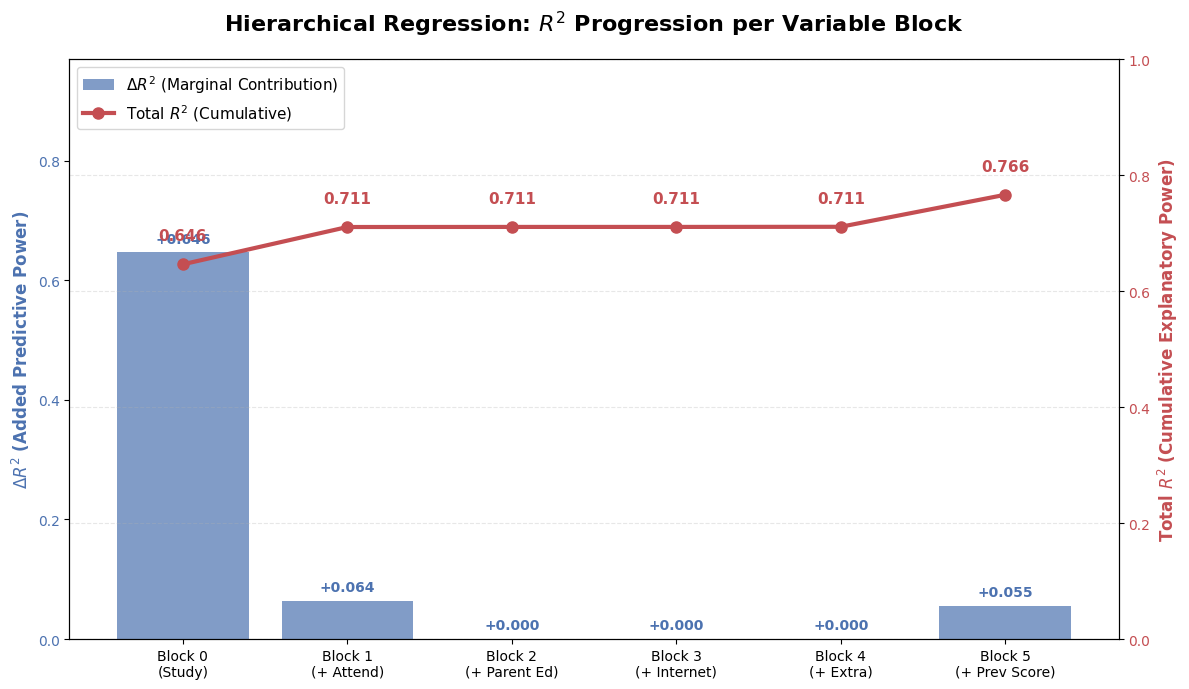

In [61]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# Posisi X
x_pos = np.arange(len(block_names))

# Plot 1: Bar chart untuk R-Square Change (ΔR²) on primary Y-axis
bars = ax1.bar(x_pos, r2_changes, color='#4C72B0', alpha=0.7, label=r'$\Delta R^2$ (Marginal Contribution)')
ax1.set_ylabel(r'$\Delta R^2$ (Added Predictive Power)', fontsize=12, color='#4C72B0', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_ylim(0, max(r2_changes) * 1.5) # Add headroom for labels

# Plot 2: Line chart untuk Total R-Square on secondary Y-axis
ax2 = ax1.twinx()
line = ax2.plot(x_pos, r2_totals, color='#C44E52', marker='o', markersize=8, linewidth=3, label=r'Total $R^2$ (Cumulative)')
ax2.set_ylabel('Total $R^2$ (Cumulative Explanatory Power)', fontsize=12, color='#C44E52', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#C44E52')
ax2.set_ylim(0, 1.0) # R-square goes from 0 to 1

# Label untuk yang Bar Chart (ΔR²)
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'+{height:.3f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 5),  # 5 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4C72B0')

# Label untuk yang Line Chart (Total ΔR²)
for i, total in enumerate(r2_totals):
    ax2.annotate(f'{total:.3f}',
                 xy=(x_pos[i], total),
                 xytext=(0, 15),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='#C44E52')

# Format sama Layout
ax1.set_xticks(x_pos)
ax1.set_xticklabels(block_names, fontsize=10)
plt.title('Hierarchical Regression: $R^2$ Progression per Variable Block', fontsize=16, fontweight='bold', pad=20)

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, fontsize=11)

plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Kesimpulan

Diberikan:
```
Model Block               | Total R²   | Δ R² (Change)  
-------------------------------------------------------
Block 0 (Study)           | 0.6463     | +0.6463 (Krusial! Menjelaskan 64.6% dari `final_score`)
Block 1 (+ Attend)        | 0.7106     | +0.0643
Block 2 (+ Parent Ed)     | 0.7107     | +0.0001
Block 3 (+ Internet)      | 0.7107     | +0.0000
Block 4 (+ Extra)         | 0.7110     | +0.0002
Block 5 (+ Prev Score)    | 0.7662     | +0.0552
```

Blok 0, mempunyai $ΔR^2$ sekitar $64.6\%$. Artinya, fitur `study_hours_per_week` menjelaskan sekitar $64.6\%$ variasi dari `final_score` (poin utama)

Blok 1, mempunyai $ΔR^2$ sekitar $6.4\%$. Artinya, fitur `attendance_rate` ikut menjelaskan sekitar $6.4\%$ variasi dari `final_score` (poin kedua)

Blok 5, mempunyai $ΔR^2$ sekitar $5.5\%$. Artinya, fitur `previous_score` ikut menjelaskan sekitar $5.5\%$ variasi dari `final_score` (poin ketiga)

Sedangkan, Blok 2 sampai dengan Blok 4 mempunyai ΔR2 yang sangat kecil, yang mendekati 0%, artinya fitur fitur tersebut tidak mempunyai kontribusi signifikan terhadap variasi `final_score`